# Shot Success Model

In [19]:
# Call jupyter notebook to load data

%run ./Load_NBA_Dataset.ipynb

In [ ]:
# Import Libraries

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
#from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.decomposition import PCA
import sklearn.metrics as metrics

## Data Prep

In [14]:
# PCA

pca = PCA(n_components=5)
pca.fit(df_encoded)
print(pca.explained_variance_ratio_)

print(pca.singular_values_)

[1.00000000e+00 3.16244303e-13 2.17631461e-13 3.00525078e-15
 1.10013452e-15]
[9.73216124e+10 5.47293954e+04 4.54014930e+04 5.33518711e+03
 3.22799008e+03]


In [22]:
data = df_encoded

In [85]:
# Data for linear regression (excludes categorical variables)

Y = pl.Series(data.select('SHOT_MADE_FLAG')).to_numpy()
X = data.select(
    ['shotDistance'
    ]
    )

x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.7)

In [ ]:
# Data for non-linear regression (includes categorical variables)
Y2 = pl.Series(data.select('SHOT_MADE_FLAG')).to_numpy()
X2 = data.select(
    ['shotDistance'
    ]
    )

x_train2, x_test2, y_train2, y_test2 = train_test_split(X, Y, train_size=0.7)

## Model Selection

### RidgeClassifier

Train & evaluate linear regression classifiers, which can only use continuous numeric input variables i.e. no encoded categorical


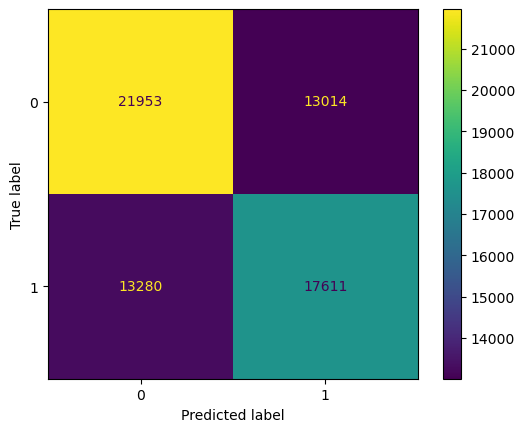

In [83]:
clf_ridge = RidgeClassifier().fit(x_train, y_train)
y_pred_ridge = clf_ridge.predict(x_test)

# Calculate & display confusion matrix
cm_ridge = metrics.confusion_matrix(y_test, y_pred_ridge)
cm_fig_ridge = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_ridge, display_labels=clf_ridge.classes_)
cm_fig_ridge.plot(values_format='d')
plt.show()

In [ ]:
# Optimisation

In [ ]:
# Cross Validation
score_ridge = cross_val_score(clf_ridge, X, Y, cv=10)
score_ridge

### Logistic Regression

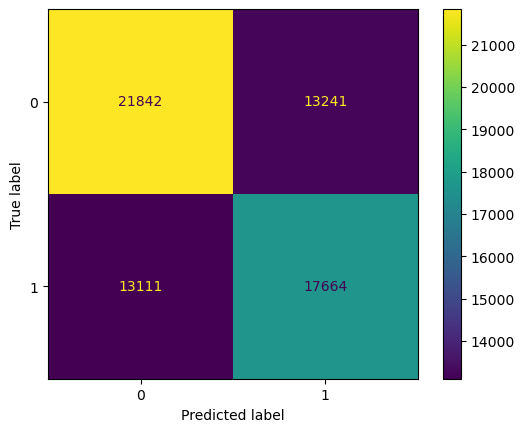

In [115]:
# Initialize and train the model
clf_log = LogisticRegression(C=10, solver='liblinear', penalty='l2').fit(x_train, y_train)
y_pred_log = clf_log.predict(x_test)

# Calculate & display confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_log)
cm_fig = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_log.classes_)
cm_fig.plot(values_format='d')
plt.show()

In [ ]:
# Optimise logistic regression hyper parameters
param_grid_log1 = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2']
}

param_grid_log2 = {
    'C': [0.1, 1, 10, 100],
    'solver': ['lbfgs'],
    'penalty': ['l2']
}

clf_log2 = LogisticRegression()

# Create & train grid_search object for param grid 1
grid_search_log1 = GridSearchCV(clf_log2, param_grid_log1, cv=5, scoring='accuracy')
grid_search_log1.fit(x_train, y_train)

print("Best set of hyperparameters from grid 1: ", grid_search_log1.best_params_)
print("Best score: ", grid_search_log1.best_score_)

# Create & train grid_search object for param grid 2
grid_search_log2 = GridSearchCV(clf_log2, param_grid_log2, cv=5, scoring='accuracy')
grid_search_log2.fit(x_train, y_train)

print("Best set of hyperparameters from grid 2: ", grid_search_log2.best_params_)
print("Best score: ", grid_search_log2.best_score_)


Best set of hyperparameters from grid 1:  {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best score:  0.6019159641991405
Best set of hyperparameters from grid 2:  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best score:  0.6018886323564029


In [ ]:
# Cross Validation
clf_log3 = LogisticRegressionCV(Cs=[1, 10, 100], cv=10, random_state=47).fit(X, Y)
scores_log = clf_log3.scores_
print(f"Scores: {scores_log}")

Score: 0.6019478508044679


### LinearSVC


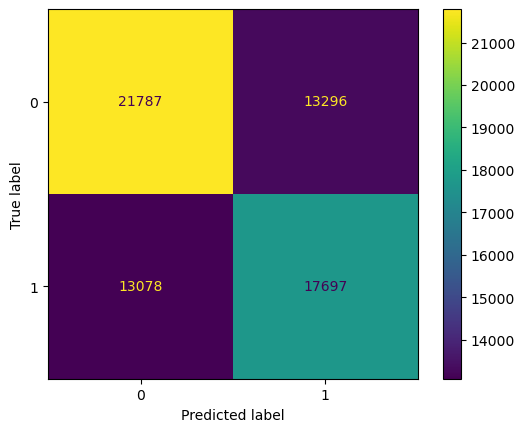

In [89]:
linear_svc = LinearSVC(max_iter=5000).fit(x_train, y_train)
y_pred_svc = linear_svc.predict(x_test)

# Calculate & display confusion matrix
cm_svc = metrics.confusion_matrix(y_test, y_pred_svc)
cm_fig_svc = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=linear_svc.classes_)
cm_fig_svc.plot(values_format='d')
plt.show()

In [ ]:
# Optimise LinearSVC



In [ ]:
# Cross Validate


### XGBoost

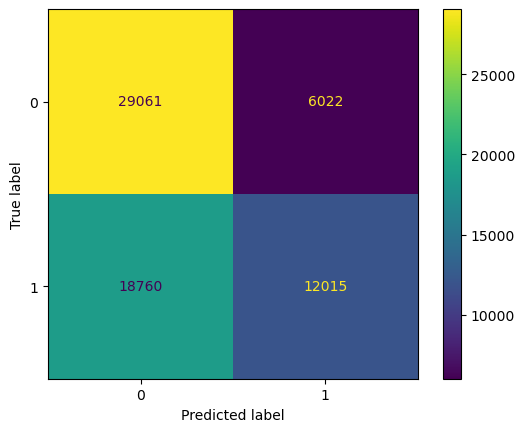

In [99]:
clf_xgb = xgb.XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=5).fit(x_train, y_train)
y_pred_xgb = clf_xgb.predict(x_test)

# Calculate & display confusion matrix
cm_xgb = metrics.confusion_matrix(y_test, y_pred_xgb)
cm_fig_xgb = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=clf_xgb.classes_)
cm_fig_xgb.plot(values_format='d')
plt.show()

In [ ]:
# Optimise XGBoost hyper parameters
XGB_param_grid = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [2, 5, 10]
}

xgb_model = xgb.XGBClassifier()

# Create & train grid_search object
grid_search = GridSearchCV(xgb_model, XGB_param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

print("Best set of hyperparameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Best set of hyperparameters:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Best score:  0.624653486172882


In [119]:
# Cross Validate
score_xgb = cross_val_score(clf_xgb, X, Y, cv=10)
score_xgb

array([0.62328611, 0.62078076, 0.62961782, 0.62132738, 0.62609329,
       0.62017128, 0.62395226, 0.62258564, 0.62418003, 0.62773324])

### Random Forest

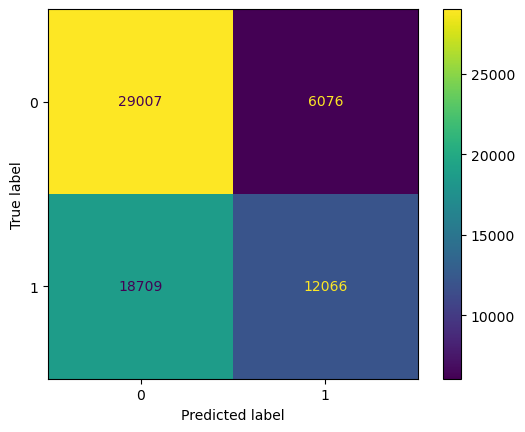

In [102]:

# Train & score classifier
clf_forest = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=45).fit(x_train, y_train)
y_pred_forest = clf_forest.predict(x_test)

# Calculate & display confusion matrix
cm_forest= metrics.confusion_matrix(y_test, y_pred_forest)
cm_fig_forest = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_forest, display_labels=clf_forest.classes_)
cm_fig_forest.plot(values_format='d')
plt.show()

In [ ]:
# Optimise Random Forest via hyper parameter tuning
param_grid_rf = {
    'n_estimators': [10, 50, 100],
    'max_depth': [2, 5, 10]
}

# Perform Grid Search
grid_search_rf = GridSearchCV(clf_forest, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(x_train, y_train)

print("Best set of hyperparameters: ", grid_search_rf.best_params_)
print("Best score: ", grid_search_rf.best_score_)

Best set of hyperparameters:  {'max_depth': 5, 'n_estimators': 100}
Best score:  0.6243606428302911


In [ ]:
# Cross Validate
score_rf = cross_val_score(clf_forest, X, Y, cv=10)
score_rf

array([0.62341381, 0.62009501, 0.61840307, 0.62601679, 0.62386933,
       0.62640724, 0.62267343, 0.62989718, 0.62631784, 0.62618769])

### Decision Tree

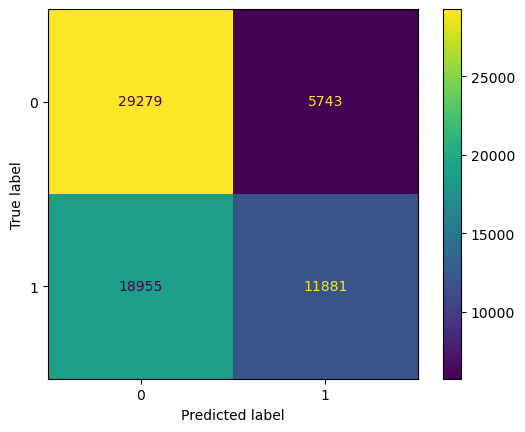

In [75]:

clf_decision = DecisionTreeClassifier(max_depth=4, min_samples_split=3, min_samples_leaf=2).fit(x_train, y_train)
y_pred_decision = clf_decision.predict(x_test)

# Calculate & display confusion matrix
cm_decision = metrics.confusion_matrix(y_test, y_pred_decision)
cm_fig_decision = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_decision, display_labels=clf_decision.classes_)
cm_fig_decision.plot(values_format='d')
plt.show()

In [121]:
# Decision Tree Optimisation - hyper parameter turning
param_grid_dt = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Grid Search
grid_search_dt = GridSearchCV(clf_forest, param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(x_train, y_train)

print("Best set of hyperparameters: ", grid_search_dt.best_params_)
print("Best score: ", grid_search_dt.best_score_)

Best set of hyperparameters:  {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score:  0.6243606428302911


In [ ]:
# Cross Validation
score_df = cross_val_score(clf_decision, X, Y, cv=10)
score_df

### Model Evaluation

Evaluate & compare model performance 

In [122]:
model_compare = {
    "LogisticRegression": "",
    "RidgeClassifer": score_ridge,
    "XGBoost": score_xgb,
    "Random Forest": score_rf,
    "Decision Tree": score_df
}

print(model_compare)

NameError: name 'score_ridge' is not defined

### Ensemble

Ensemble classifier ??